# import datasets and data preprocessing

In [ ]:
# importing pandas library and start importing datasets

import pandas as pd
pd.set_option('display.max_columns', None)
# first dataset have Paris real estate transactions
df1 = pd.read_csv('dvf.csv')
df1.head(2)

/tmp/ipykernel_599/2530210657.py:6: DtypeWarning:

Columns (2,4,5,8,9,10,12,13,14,16,17,18,19,20,21,22,23,24,25,26,27,28,29,31,32,35,36,37,38,39) have mixed types. Specify dtype option on import or set low_memory=False.



,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,ancien_code_commune,ancien_nom_commune,id_parcelle,ancien_id_parcelle,numero_volume,lot1_numero,lot1_surface_carrez,lot2_numero,lot2_surface_carrez,lot3_numero,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,section_prefixe
0,2023-1337583,2023-10-11,1,Vente,9976270.0,NaN,NaN,NaN,NaN,NaN,75101,Paris 1er Arrondissement,75,NaN,NaN,75101000AO0001,NaN,35720.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.345729,48.860977,000AO
1,2023-1337583,2023-10-11,1,Vente,9976270.0,NaN,NaN,NaN,NaN,NaN,75101,Paris 1er Arrondissement,75,NaN,NaN,75101000AO0001,NaN,23120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.345729,48.860977,000AO


In [ ]:
# see info and types
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420066 entries, 0 to 420065
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   id_mutation                   420066 non-null  object
 1   date_mutation                 420066 non-null  object
 2   numero_disposition            420066 non-null  object
 3   nature_mutation               420066 non-null  object
 4   valeur_fonciere               414641 non-null  object
 5   adresse_numero                418317 non-null  object
 6   adresse_suffixe               18358 non-null   object
 7   adresse_nom_voie              418372 non-null  object
 8   adresse_code_voie             418372 non-null  object
 9   code_postal                   418367 non-null  object
 10  code_commune                  420066 non-null  object
 11  nom_commune                   420066 non-null  object
 12  code_departement              420066 non-null  object
 13 

In [ ]:
# see how many null values
df1.isnull().sum()

,0
id_mutation,0
date_mutation,0
numero_disposition,0
nature_mutation,0
valeur_fonciere,5425
adresse_numero,1749
adresse_suffixe,401708
adresse_nom_voie,1694
adresse_code_voie,1694
code_postal,1699


In [ ]:
# see duplicates
df1.duplicated().sum()

np.int64(97574)

In [ ]:
# droping unneded columns
# column that dont add any insights or have a lot of nulls

columns_ToDrop = ['adresse_numero', 'adresse_suffixe', 'numero_disposition',
                  'ancien_nom_commune', 'adresse_code_voie', 'ancien_id_parcelle', 'ancien_code_commune',
                  'id_parcelle', 'lot1_numero', 'lot2_numero', 'lot4_numero', 'lot5_numero',
                  'lot3_numero', 'numero_volume', 'code_nature_culture_speciale', 'lot2_surface_carrez',
                  'lot3_surface_carrez', 'lot5_surface_carrez', 'lot4_surface_carrez', 'code_nature_culture']

df1.drop(columns=columns_ToDrop, inplace=True)

In [ ]:
# convert column to correct type (cateogry and numerical)
df1['date_mutation'] = pd.to_datetime(df1['date_mutation'], errors='coerce')

numeric_cols_df1 = ['valeur_fonciere', 'code_postal', 'nombre_lots', 'surface_terrain',
                    'surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude',
                    'lot1_surface_carrez']
for Col in numeric_cols_df1:
    df1[Col] = pd.to_numeric(df1[Col], errors='coerce')

categ_cols_df1 = ['id_mutation','nature_mutation', 'code_commune', 'nom_commune', 'section_prefixe',
                  'code_departement', 'code_type_local', 'type_local', 'nature_culture',
                  'nature_culture_speciale']
for Col in categ_cols_df1:
    df1[Col] = df1[Col].astype('category')

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420066 entries, 0 to 420065
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id_mutation                420066 non-null  category      
 1   date_mutation              420058 non-null  datetime64[ns]
 2   nature_mutation            420066 non-null  category      
 3   valeur_fonciere            414633 non-null  float64       
 4   adresse_nom_voie           418372 non-null  object        
 5   code_postal                418359 non-null  float64       
 6   code_commune               420066 non-null  category      
 7   nom_commune                420066 non-null  category      
 8   code_departement           420066 non-null  category      
 9   lot1_surface_carrez        160596 non-null  float64       
 10  nombre_lots                420058 non-null  float64       
 11  code_type_local            415286 non-null  category

In [ ]:
# create speerate month, quarter and year oclumns
df1['year'] = df1['date_mutation'].dt.year
df1['Month'] = df1['date_mutation'].dt.month
df1['Quarter'] = df1['date_mutation'].dt.quarter
df1['dayofweek'] = df1['date_mutation'].dt.dayofweek

In [ ]:
# translate remaining columns
df1 = df1.rename(columns={'id_mutation':'transaction_id',
                          'date_mutation':'date', 'nature_mutation':"transaction_type", 'valeur_fonciere':'property_value',
                          'adresse_nom_voie':'street_name', 'code_postal':'postal_code', 'code_commune':'municipality_code','nom_commune':'municipality_name',
                          'lot1_surface_carrez':"1st_lot_surface_area", 'nombre_lots':'number_of_lots', "code_type_local":'property_type_code',
                          'type_local':'property_type', 'surface_reelle_bati':'actual_building_surface_area', 'nature_culture':'land_use_type',
                          'nombre_pieces_principales':"number_of_main_rooms", "nature_culture_speciale":"Special_Nature_and_Culture"})
df1.head(2)

,transaction_id,date,transaction_type,property_value,street_name,postal_code,municipality_code,municipality_name,code_departement,1st_lot_surface_area,number_of_lots,property_type_code,property_type,actual_building_surface_area,number_of_main_rooms,land_use_type,Special_Nature_and_Culture,surface_terrain,longitude,latitude,section_prefixe,year,Month,Quarter,dayofweek
0,2023-1337583,2023-10-11,Vente,9976270.0,NaN,NaN,75101,Paris 1er Arrondissement,75,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.345729,48.860977,000AO,2023.0,10.0,4.0,2.0
1,2023-1337583,2023-10-11,Vente,9976270.0,NaN,NaN,75101,Paris 1er Arrondissement,75,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.345729,48.860977,000AO,2023.0,10.0,4.0,2.0


In [ ]:
# check percent of null values in some remaining columns
# if percent is high than rmeove them
print(df1['1st_lot_surface_area'].isnull().mean()*100)
print(df1['surface_terrain'].isnull().mean()*100)
print(df1['number_of_lots'].isnull().mean()*100)
print(df1['Special_Nature_and_Culture'].isnull().mean()*100)
print(df1['land_use_type'].isnull().mean()*100)

61.76886489265973
90.85857936609962
0.0019044626320625809
99.85526083996325
90.85667490346755


In [ ]:
# droping the ones with many null values

more_cols_drop = ['1st_lot_surface_area', 'surface_terrain', 'Special_Nature_and_Culture', 'land_use_type']
df1.drop(columns=more_cols_drop, inplace=True)

In [ ]:
# chekc cateogries in columns to translate them
print(df1['transaction_type'].unique())
print(df1['property_type'].unique())

['Vente', 'Vente en l'état futur d'achèvement', 'Echange', 'Adjudication', 'Expropriation', 'Vente terrain à bâtir', 'nature_mutation']
Categories (7, object): ['Adjudication', 'Echange', 'Expropriation', 'Vente',
                         'Vente en l'état futur d'achèvement', 'Vente terrain à bâtir', 'nature_mutation']
[NaN, 'Local industriel. commercial ou assimilé', 'Appartement', 'Dépendance', 'Maison', 'type_local']
Categories (5, object): ['Appartement', 'Dépendance', 'Local industriel. commercial ou assimilé',
                         'Maison', 'type_local']


In [ ]:
df1['transaction_type'] = df1['transaction_type'].replace({'Vente':'Sale', "Vente en l'état futur d'achèvement":"Sale in future after completion",
                                                           'Echange':'Exchange/Swap', 'Adjudication':'Auction', 'Expropriation':'Compulsory purchase',
                                                           'Vente terrain à bâtir':'sale of building land', 'nature_mutation':'transfer type'})
df1['property_type'] = df1['property_type'].replace({'Appartement':'Appartment', 'Local industriel. commercial ou assimilé':'Industrial, commerical or similar premises',
                                                     'Dépendance':'Dependency', 'Maison':'Home', 'type_local':'property type' })

/tmp/ipykernel_599/1229671863.py:1: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.

/tmp/ipykernel_599/1229671863.py:4: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



In [ ]:
# check few rows from dataset to see the changes
df1.head()

,transaction_id,date,transaction_type,property_value,street_name,postal_code,municipality_code,municipality_name,code_departement,number_of_lots,property_type_code,property_type,actual_building_surface_area,number_of_main_rooms,longitude,latitude,section_prefixe,year,Month,Quarter,dayofweek
0,2023-1337583,2023-10-11,Sale,9976270.0,NaN,NaN,75101,Paris 1er Arrondissement,75,0.0,NaN,NaN,NaN,NaN,2.345729,48.860977,000AO,2023.0,10.0,4.0,2.0
1,2023-1337583,2023-10-11,Sale,9976270.0,NaN,NaN,75101,Paris 1er Arrondissement,75,0.0,NaN,NaN,NaN,NaN,2.345729,48.860977,000AO,2023.0,10.0,4.0,2.0
2,2023-1337582,2023-10-11,Sale,5719815.5,PAS ANTOINE CAREME,75001.0,75101,Paris 1er Arrondissement,75,0.0,NaN,NaN,NaN,NaN,2.345729,48.860977,000AO,2023.0,10.0,4.0,2.0
3,2023-1322039,2023-01-03,Sale,1825000.0,RUE SAINT-DENIS,75001.0,75101,Paris 1er Arrondissement,75,7.0,4.0,"Industrial, commerical or similar premises",165.0,0.0,2.349112,48.862083,000AP,2023.0,1.0,1.0,1.0
4,2023-1322040,2023-01-05,Sale,567000.0,RUE DE L ECHIQUIER,75010.0,75110,Paris 10e Arrondissement,75,2.0,4.0,"Industrial, commerical or similar premises",52.0,0.0,2.348283,48.871818,000AV,2023.0,1.0,1.0,3.0


In [ ]:
# use engine python and sep none so that python can detect seperator and fetch dataste
df2 = pd.read_csv('logement-encadrement-des-loyers.csv', engine='python', sep=None)
df2.head(3)

,﻿Année,Secteurs géographiques,Numéro du quartier,Nom du quartier,Nombre de pièces principales,Epoque de construction,Type de location,Loyers de référence,Loyers de référence majorés,Loyers de référence minorés,Ville,Numéro INSEE du quartier,geo_shape,geo_point_2d
0,2023,8,57,Saint-Lambert,1,1971-1990,meublé,28.3,34.0,19.8,PARIS,7511557,"{""coordinates"": [[[2.3042487966491323, 48.8404...","48.83429362836976, 2.296919974448867"
1,2024,10,67,Batignolles,1,1946-1970,non meublé,26.1,31.3,18.3,PARIS,7511767,"{""coordinates"": [[[2.317210277038245, 48.89025...","48.888481513920595, 2.313856169006357"
2,2024,9,69,Grandes-Carrières,4,1946-1970,meublé,21.1,25.3,14.8,PARIS,7511869,"{""coordinates"": [[[2.340216773881389, 48.89310...","48.89257777114592, 2.334363089913081"


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17920 entries, 0 to 17919
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ﻿Année                        17920 non-null  int64  
 1   Secteurs géographiques        17920 non-null  int64  
 2   Numéro du quartier            17920 non-null  int64  
 3   Nom du quartier               17920 non-null  object 
 4   Nombre de pièces principales  17920 non-null  int64  
 5   Epoque de construction        17920 non-null  object 
 6   Type de location              17920 non-null  object 
 7   Loyers de référence           17920 non-null  float64
 8   Loyers de référence majorés   17920 non-null  float64
 9   Loyers de référence minorés   17920 non-null  float64
 10  Ville                         17920 non-null  object 
 11  Numéro INSEE du quartier      17920 non-null  int64  
 12  geo_shape                     17920 non-null  object 
 13  g

In [ ]:
df2.isnull().sum()

,0
﻿Année,0
Secteurs géographiques,0
Numéro du quartier,0
Nom du quartier,0
Nombre de pièces principales,0
Epoque de construction,0
Type de location,0
Loyers de référence,0
Loyers de référence majorés,0
Loyers de référence minorés,0


In [ ]:
df2.duplicated().sum()

np.int64(0)

In [ ]:
Cols_drop_df2 = ['Ville', 'geo_shape', 'Numéro INSEE du quartier']
df2.drop(columns=Cols_drop_df2, inplace=True)

In [ ]:
# see columns names to write correctly when trnaslating
df2.columns.tolist()

['\ufeffAnnée',
 'Secteurs géographiques',
 'Numéro du quartier',
 'Nom du quartier',
 'Nombre de pièces principales',
 'Epoque de construction',
 'Type de location',
 'Loyers de référence',
 'Loyers de référence majorés',
 'Loyers de référence minorés',
 'geo_point_2d']

In [ ]:
# remove \ufeff
df2.columns = df2.columns.str.replace('\ufeff', '', regex=False)

# translate remianing columns
df2 = df2.rename(columns={'Année':'Year', 'Secteurs géographiques':'Geogrpahic_sectors', 'Numéro du quartier':'District_number',"Nom du quartier":'District_name',
                          'Nombre de pièces principales':'number_of_main_rooms', "Type de location":"Rental_Type", "Epoque de construction":'Construction_Period',
                          'Loyers de référence':"Reference_rent", 'Loyers de référence majorés':'higher_reference_rate','Loyers de référence minorés':"Lower_reference_rate",
                          'geo_point_2d':"geo_points_coordinates"})
df2.head(2)

,Year,Geogrpahic_sectors,District_number,District_name,number_of_main_rooms,Construction_Period,Rental_Type,Reference_rent,higher_reference_rate,Lower_reference_rate,geo_points_coordinates
0,2023,8,57,Saint-Lambert,1,1971-1990,meublé,28.3,34.0,19.8,"48.83429362836976, 2.296919974448867"
1,2024,10,67,Batignolles,1,1946-1970,non meublé,26.1,31.3,18.3,"48.888481513920595, 2.313856169006357"


In [ ]:
df2['Rental_Type'].unique()

array(['meublé', 'non meublé'], dtype=object)

In [ ]:
df2['Rental_Type'] = df2['Rental_Type'].replace({'meublé':'furinshed','non meublé':'unfurinshed'})

In [ ]:
# import and do same with the 3rd dataset
df3 = pd.read_csv('plub_elpv.csv', sep=None, engine='python')
df3.head(3)

,﻿objectid_12,n_sq_elpv,arrondissement,c_sec,n_pc,c_asp,st_area(shape),st_perimeter(shape),geo_shape,geo_point_2d
0,10773,9368,20,AP,126,20-AP-0126,43.036296,26.481997,"{""coordinates"": [[[2.391939596972359, 48.87027...","48.87027151851054, 2.3918881941727923"
1,10775,6729,16,BS,66,16-BS-0066,16.717423,20.189263,"{""coordinates"": [[[2.265099705954975, 48.85270...","48.8527272782648, 2.265055511535817"
2,10786,131,17,DP,142,17-DP-0142,25.929504,22.479009,"{""coordinates"": [[[2.3225564576570843, 48.8961...","48.89612169323919, 2.322497698304243"


In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7268 entries, 0 to 7267
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ﻿objectid_12         7268 non-null   int64  
 1   n_sq_elpv            7268 non-null   int64  
 2   arrondissement       7268 non-null   int64  
 3   c_sec                7136 non-null   object 
 4   n_pc                 7268 non-null   int64  
 5   c_asp                7136 non-null   object 
 6   st_area(shape)       7268 non-null   float64
 7   st_perimeter(shape)  7268 non-null   float64
 8   geo_shape            7268 non-null   object 
 9   geo_point_2d         7268 non-null   object 
dtypes: float64(2), int64(4), object(4)
memory usage: 567.9+ KB


In [ ]:
df3.isnull().sum()

,0
﻿objectid_12,0
n_sq_elpv,0
arrondissement,0
c_sec,132
n_pc,0
c_asp,132
st_area(shape),0
st_perimeter(shape),0
geo_shape,0
geo_point_2d,0


In [ ]:
df3.duplicated().sum()

np.int64(0)

In [ ]:
df3.columns.tolist()

['\ufeffobjectid_12',
 'n_sq_elpv',
 'arrondissement',
 'c_sec',
 'n_pc',
 'c_asp',
 'st_area(shape)',
 'st_perimeter(shape)',
 'geo_shape',
 'geo_point_2d']

In [ ]:
df3.columns = df3.columns.str.replace('\ufeff', '', regex=False)

Cols_drop_df3 = ['objectid_12', 'geo_shape', 'n_pc', 'n_sq_elpv', 'c_asp']
df3.drop(columns=Cols_drop_df3, inplace=True)

In [ ]:
df3 = df3.rename(columns={'arrondissement':'District', 'c_sec':'Cadastral_section_code', 'st_area(shape)':'Surface_area_geometry',
                          'st_perimeter(shape)':'Perimeter_geometry', 'geo_point_2d':'geo_points_coordinates'})
df3.head(2)

,District,Cadastral_section_code,Surface_area_geometry,Perimeter_geometry,geo_points_coordinates
0,20,AP,43.036296,26.481997,"48.87027151851054, 2.3918881941727923"
1,16,BS,16.717423,20.189263,"48.8527272782648, 2.265055511535817"


In [ ]:
# chekc cadastral section code to see how many values it have
df3['Cadastral_section_code'].unique()

array(['AP', 'BS', 'DP', 'DW', 'DI', 'BI', 'CQ', 'EU', 'CO', 'EB', 'AM',
       'DH', 'FZ', 'DK', 'AD', 'BR', 'DE', 'DV', 'EA', 'DZ', 'AI', 'CN',
       'AR', 'DJ', 'ED', 'EV', 'DL', 'BL', 'CT', 'AC', 'AO', 'EK', 'CP',
       'AS', 'AV', 'AE', 'ES', 'DN', 'DM', 'BN', 'FB', 'CH', 'DG', 'BK',
       'CV', 'CM', 'CI', 'EW', 'AJ', 'AY', 'BM', 'BU', 'AU', 'EX', 'ER',
       'AW', 'BY', 'CF', 'DO', 'AT', 'DR', 'EN', 'EC', 'CW', 'AB', 'AG',
       'BJ', 'EI', 'BT', 'BX', 'CX', 'BW', 'CK', 'BQ', 'CR', 'CE', 'CL',
       'BZ', nan, '20', 'CG', 'DF', 'AL', 'FC', 'BC', 'DB', 'FU', 'DU',
       'AH', 'BO', 'BV', 'AX', 'AN', 'EE', 'FL', 'DD', 'EG', 'ET', 'DQ',
       'FA', 'CB', 'AQ', 'CD', 'BE', 'BP', 'CC', 'EM', 'EH', 'DS', 'BH',
       'BB', 'AZ', 'DX', 'FF', 'AF', 'EF', 'BA', 'DT', 'FV', 'BD', 'DY',
       'CZ', 'AK', 'CS', 'BF', 'DA', 'AA', 'BG', 'GI', 'FG', 'FE', 'DC',
       'CU', 'FY', 'EL', 'CY', 'EQ', 'EJ', 'CJ', 'CA', 'EO', 'FD', 'EY',
       'EP', 'EZ'], dtype=object)

In [ ]:
df4 = pd.read_csv('plub_pprizone.csv', sep=None, engine='python')
df4.head(2)

,﻿OBJECTID,zonage,n_sq_pprizone,st_area(shape),st_perimeter(shape),geo_shape,geo_point_2d
0,571,BS,571,720.485643,164.565764,"{""coordinates"": [[[2.3252953465938084, 48.8599...","48.860155123053985, 2.325017927464804"
1,624,BC,650,12866.420126,645.686724,"{""coordinates"": [[[2.3310929665869145, 48.8588...","48.85837601257902, 2.331476516237963"


In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ﻿OBJECTID            1653 non-null   int64  
 1   zonage               1653 non-null   object 
 2   n_sq_pprizone        1653 non-null   int64  
 3   st_area(shape)       1653 non-null   float64
 4   st_perimeter(shape)  1653 non-null   float64
 5   geo_shape            1653 non-null   object 
 6   geo_point_2d         1653 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 90.5+ KB


In [ ]:
df4.isnull().sum()

,0
﻿OBJECTID,0
zonage,0
n_sq_pprizone,0
st_area(shape),0
st_perimeter(shape),0
geo_shape,0
geo_point_2d,0


In [ ]:
df4.duplicated().sum()

np.int64(0)

In [ ]:
df4.columns.tolist()

['\ufeffOBJECTID',
 'zonage',
 'n_sq_pprizone',
 'st_area(shape)',
 'st_perimeter(shape)',
 'geo_shape',
 'geo_point_2d']

In [ ]:
df4.columns = df4.columns.str.replace('\ufeff', '', regex=False)
Cols_drop_df4 = ['OBJECTID', 'geo_shape', 'n_sq_pprizone']
df4.drop(columns=Cols_drop_df4, inplace=True)

In [ ]:
df4 = df4.rename(columns={'zonage':'zoning_risk_classification', 'st_area(shape)':'Surface_area_geometry',
                          "st_perimeter(shape)":"Perimeter_geometry", 'geo_point_2d':'geo_points_coordinates'})
df4.head(2)

,zoning_risk_classification,Surface_area_geometry,Perimeter_geometry,geo_points_coordinates
0,BS,720.485643,164.565764,"48.860155123053985, 2.325017927464804"
1,BC,12866.420126,645.686724,"48.85837601257902, 2.331476516237963"


In [ ]:
df4['zoning_risk_classification'].unique()

array(['BS', 'BC', 'BCH', 'R', 'BSH', 'V'], dtype=object)

In [ ]:
df4['zoning_risk_classification'] = df4['zoning_risk_classification'].replace({"BC":"light blue",
                                     'BCH':"Light blue hatched", "BS":"Dark Blue Zone", 'BSH':"Dark Blue hatched",
                                           'V':'Green zone', 'R':'Red zone'})
df4['zoning_risk_classification'].unique()
# color red most dangeorus, then BSH, BS, then BCH, BC and green last

array(['Dark Blue Zone', 'light blue', 'Light blue hatched', 'Red zone',
       'Dark Blue hatched', 'Green zone'], dtype=object)

# more preprocessing

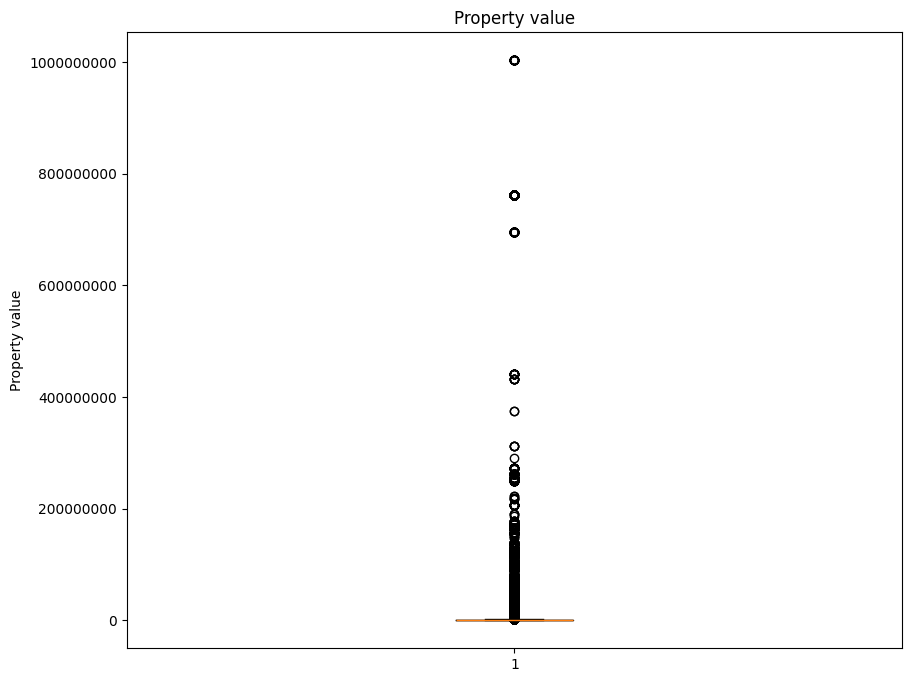

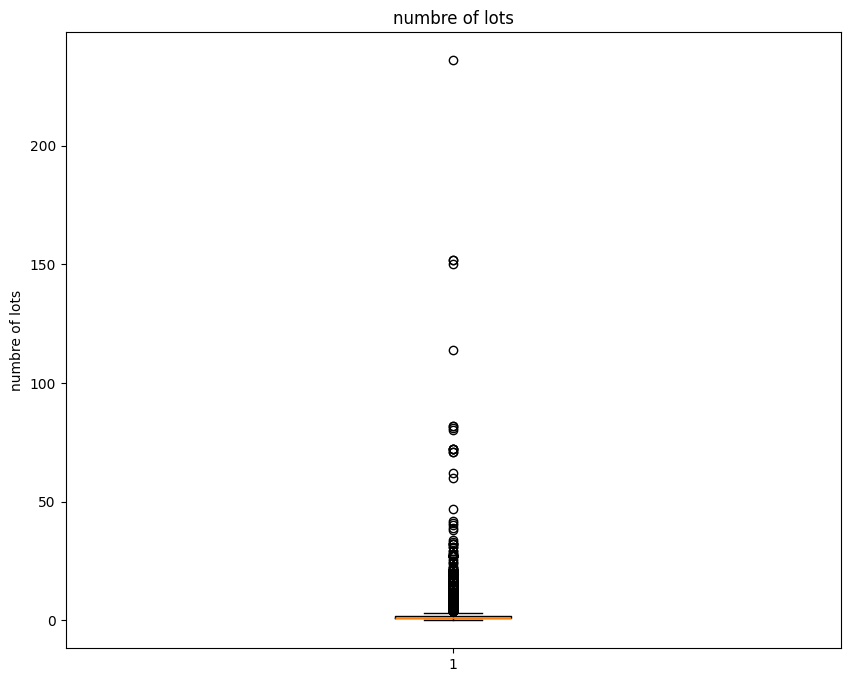

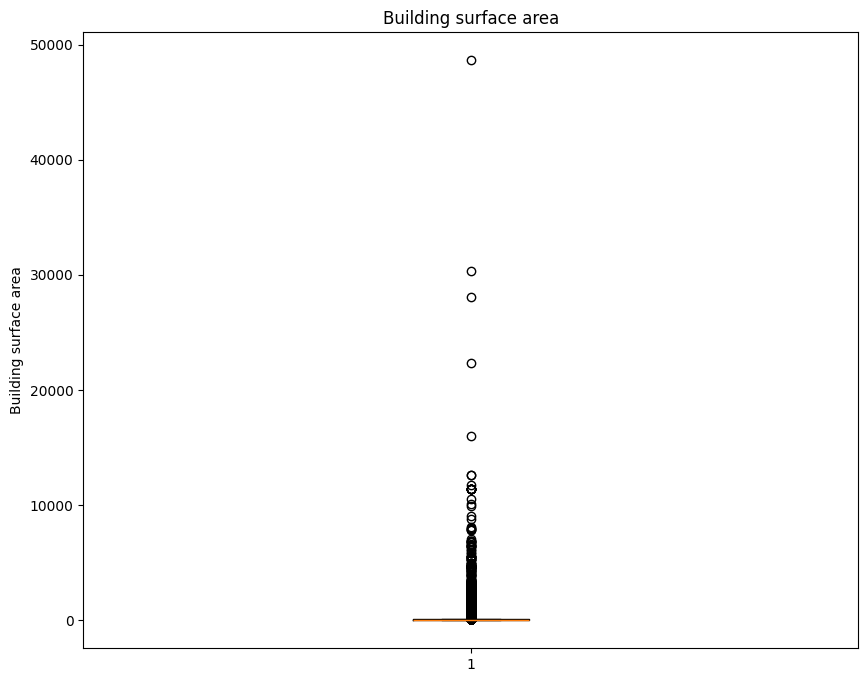

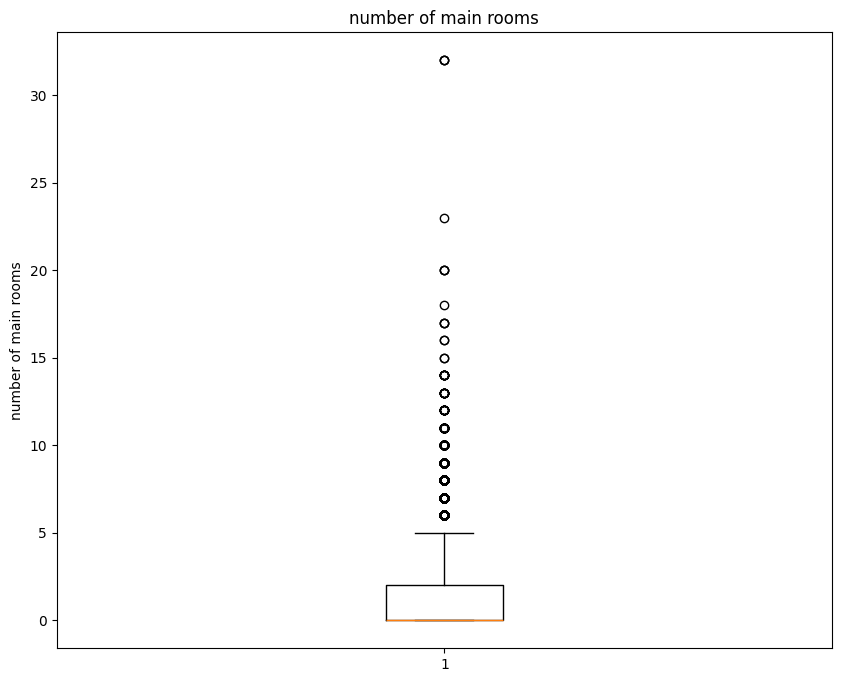

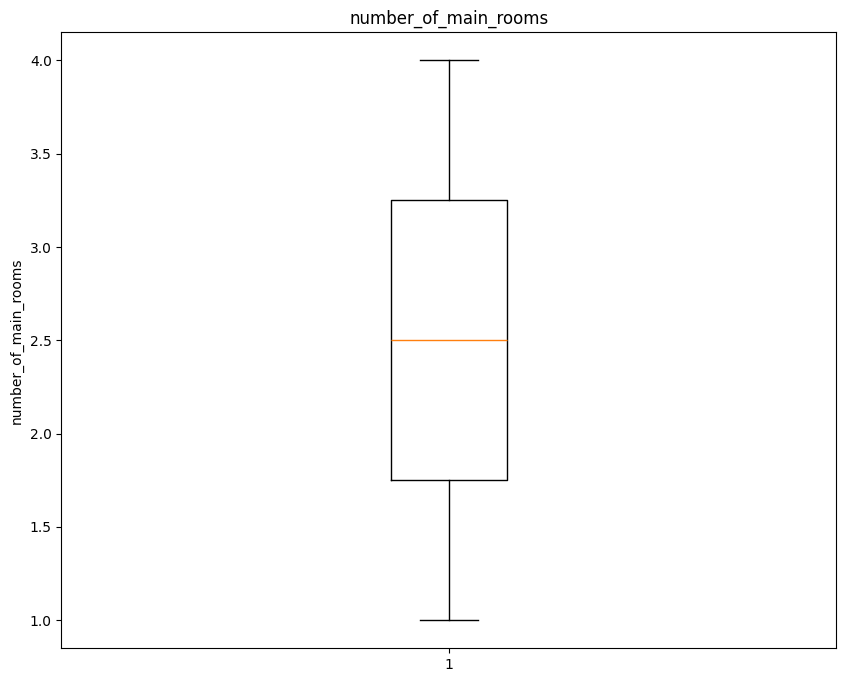

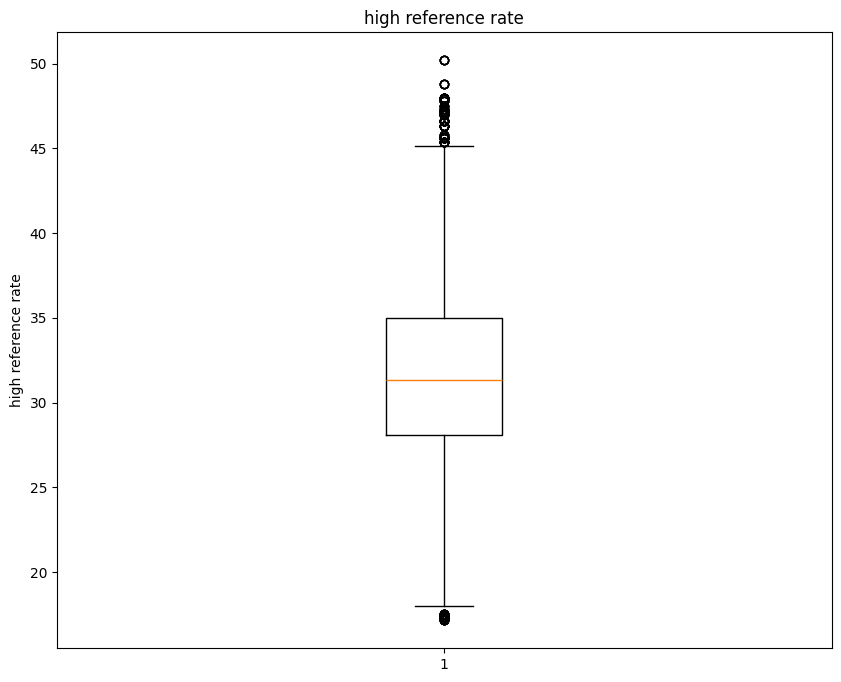

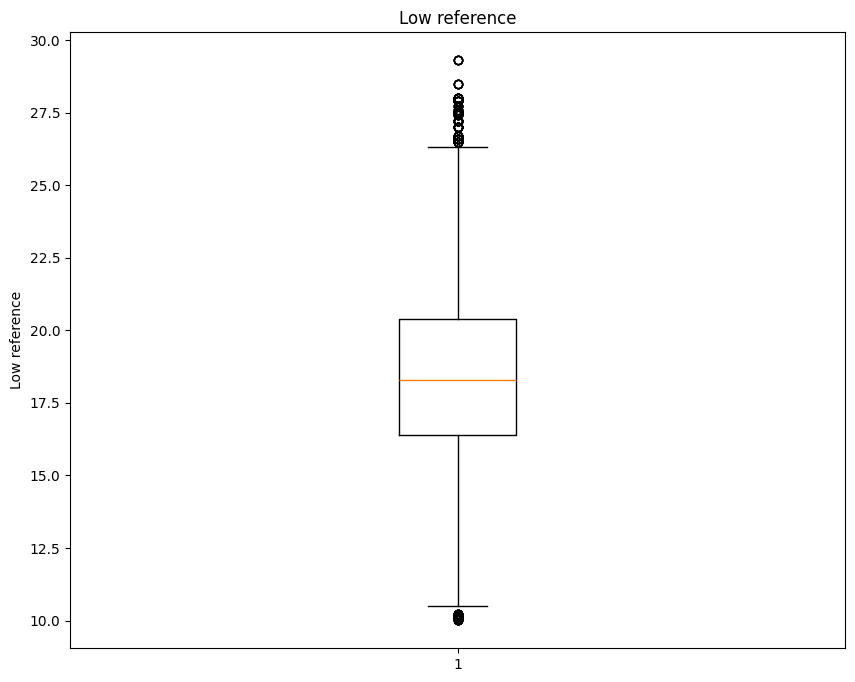

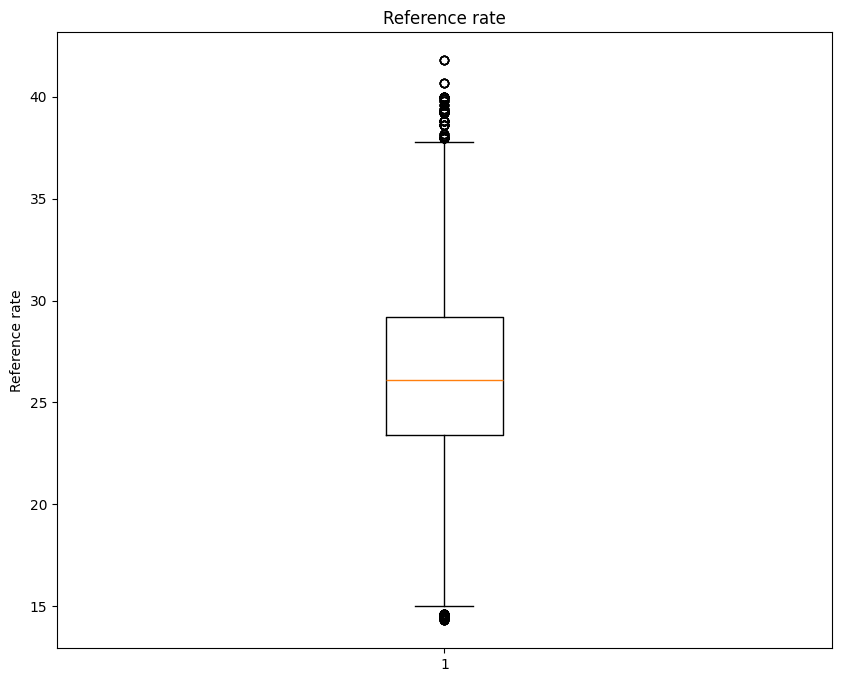

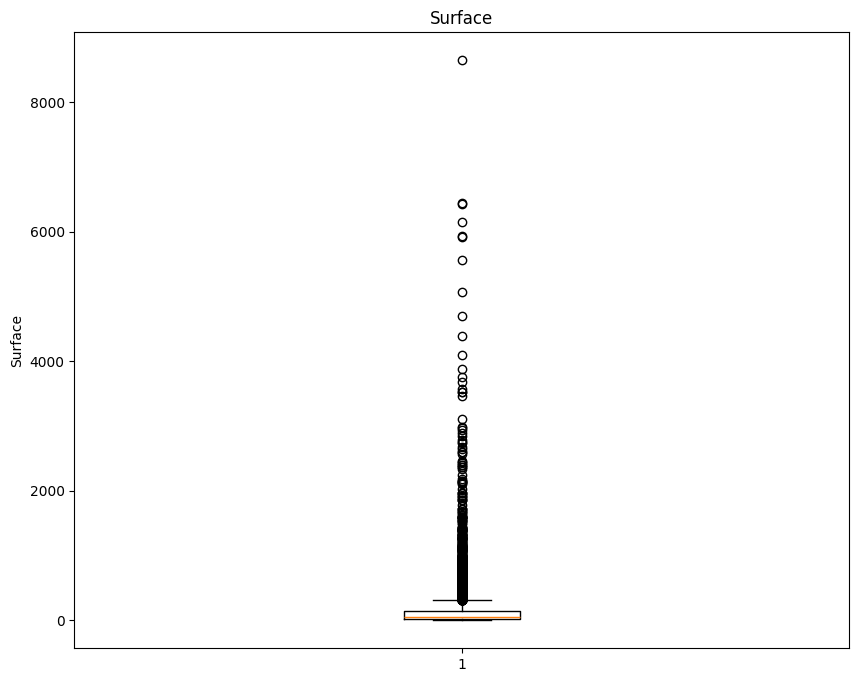

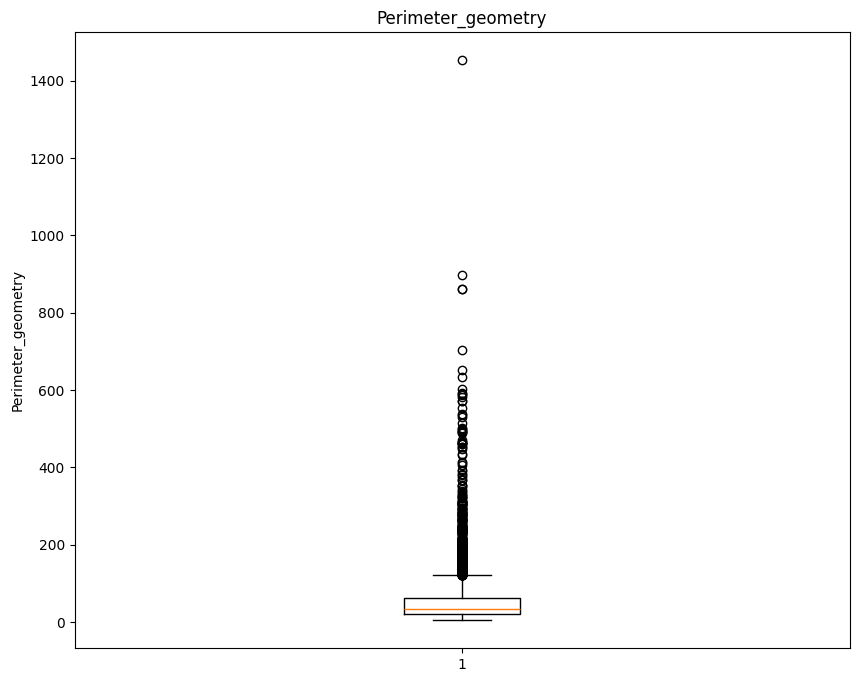

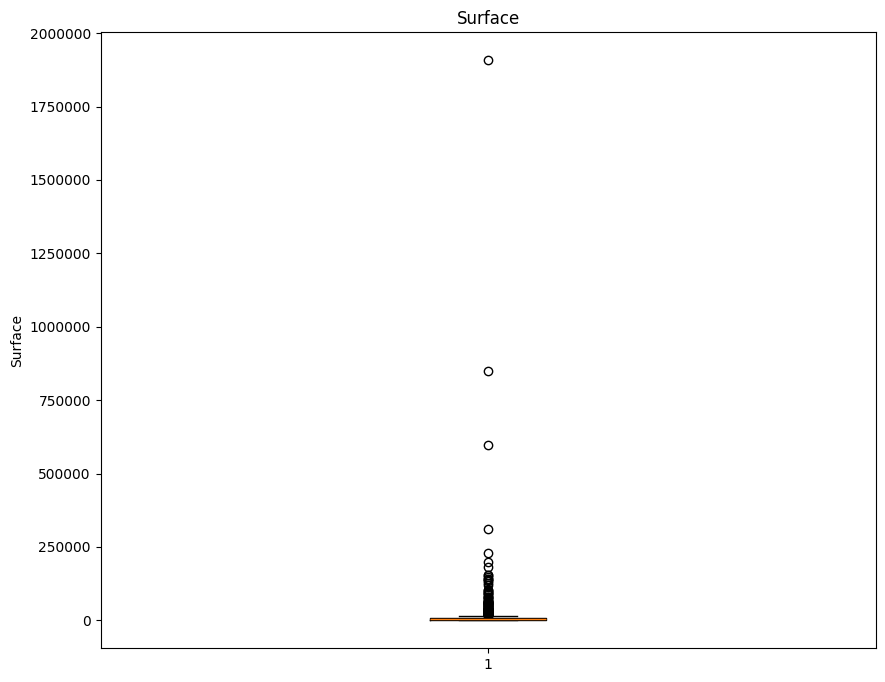

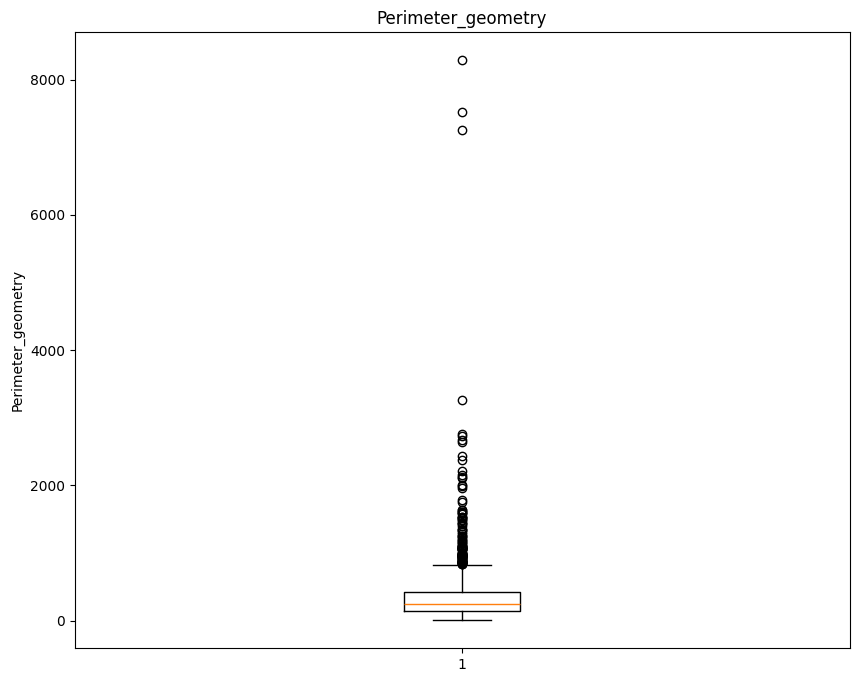

In [ ]:
import matplotlib.pyplot as plt


columns_boxplots = [(df1['property_value'].dropna(), "Property value"),
                    (df1['number_of_lots'].dropna(), "numbre of lots"), (df1['actual_building_surface_area'].dropna(), 'Building surface area'),
                    (df1['number_of_main_rooms'].dropna(), "number of main rooms"),
                    (df2['number_of_main_rooms'].dropna(), "number_of_main_rooms"), (df2['higher_reference_rate'].dropna(), "high reference rate"),
                    (df2['Lower_reference_rate'].dropna(), "Low reference"), (df2['Reference_rent'].dropna(), "Reference rate"),
                    (df3['Surface_area_geometry'].dropna(), "Surface"), (df3['Perimeter_geometry'].dropna(), "Perimeter_geometry"),
                    (df4['Surface_area_geometry'].dropna(), "Surface"), (df4['Perimeter_geometry'].dropna(), "Perimeter_geometry")]

for i, (data, name) in enumerate(columns_boxplots, 1):
    plt.figure(figsize=(10,8))
    plt.boxplot(data)
    plt.title(name)
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylabel(name)
    plt.show()

In [ ]:
# since porprty vlaues in themsot imprtant, i will also look for smalelest vlaues to rmove
n= int(len(df1)*0.005)
df1['property_value'].nsmallest(n)

,property_value
4148,0.15
4211,0.15
4212,0.15
4213,0.15
40761,0.15
...,...
89643,1000.00
92925,1000.00
95782,1000.00
95783,1000.00


In [ ]:
# remove far outlier for better visualizaiotn
df1 = df1[df1['property_value'] < 10000000]
df1 = df1[df1['property_value'] > 1000]
df1 = df1[df1['number_of_lots'] < 50]
df1 = df1[df1['actual_building_surface_area'] < 10000]
df1 = df1[df1['number_of_main_rooms'] < 15]

df2 = df2[df2['Reference_rent'] < 38]
df2 = df2[df2['Reference_rent'] > 15]
df2 = df2[df2['higher_reference_rate'] < 45]
df2 = df2[df2['higher_reference_rate'] > 20]
df2 = df2[df2['Lower_reference_rate'] < 27.5]
df2 = df2[df2['Lower_reference_rate'] > 11]

df3 = df3[df3['Surface_area_geometry'] < 2000]
df3 = df3[df3['Perimeter_geometry'] < 200]

df4 = df4[df4['Surface_area_geometry'] < 250000]
df4 = df4[df4['Perimeter_geometry'] < 1000]

In [ ]:
# chekc more null vlaeus to delete to see more columns need deltion
NaN_perc1= (df1.isnull().sum()/len(df1))*100
NaN_perc2= (df2.isnull().sum()/len(df2))*100
NaN_perc3= (df3.isnull().sum()/len(df3))*100
NaN_perc4= (df4.isnull().sum()/len(df4))*100
print(NaN_perc1, NaN_perc2, NaN_perc3, NaN_perc4)

transaction_id                  0.000000
date                            0.000000
transaction_type                0.000000
property_value                  0.000000
street_name                     0.000000
postal_code                     0.000996
municipality_code               0.000000
municipality_name               0.000000
code_departement                0.000000
number_of_lots                  0.000000
property_type_code              0.000000
property_type                   0.000000
actual_building_surface_area    0.000000
number_of_main_rooms            0.000000
longitude                       0.163347
latitude                        0.163347
section_prefixe                 0.000000
year                            0.000000
Month                           0.000000
Quarter                         0.000000
dayofweek                       0.000000
dtype: float64 Year                      0.0
Geogrpahic_sectors        0.0
District_number           0.0
District_name             0.0
numb

In [ ]:
# dlete null values
df1 = df1.dropna()
df2 = df2.dropna()
df3 = df3.dropna()
df4 = df4.dropna()

In [ ]:
# see duplicates to see what to delete
df1dup = df1.duplicated().sum()
df2dup = df2.duplicated().sum()
df3dup = df3.duplicated().sum()
df4dup = df4.duplicated().sum()
print(df1dup, df2dup, df3dup, df4dup)

44568 0 1 0


In [ ]:
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()
df3 = df3.drop_duplicates()
df4 = df4.drop_duplicates()

# Link datasets using geo locations

In [ ]:
# 1) import library for deaing wth geospatial data
import geopandas as gpd
# numpy for mathemtical fucntions
import numpy as np
# import ckdtree to search for nearest neighbosr and spatial indeixng for points
from scipy.spatial import cKDTree

# 2_ copy datasets and creta keys
df1 = df1.copy()
df2 = df2.copy()
df3 = df3.copy()
df4 = df4.copy()
# create keys to manually merge tasks later
df2['ReferenceID'] = range(1,len(df2)+1)
df3['ELPV_ID'] = range(1,len(df3)+1)
df4['PPRI_ID'] = range(1,len(df4)+1)

In [ ]:
# 3_ extract coordinates from geo point coordinates
# deifne fucntion to seperate geo points coordinates to latitudue and longtiude
def extract_coordinates(df):
    df[['latitude', 'longitude']] = (
        df['geo_points_coordinates'].str.split(',', expand=True).astype(float))
    return df
df2 = extract_coordinates(df2)
df3 = extract_coordinates(df3)
df4 = extract_coordinates(df4)

In [ ]:
# 4_ create geographic GeoDataFrame

# create geodataframe for df2, use longtidue and latitude to generate the points
# base don WGS84 geo coords system, new datasets only have new IDs and longitude and latitude
# it make points from the longitud and altitude columns
gdf_Reference = gpd.GeoDataFrame(df2[["ReferenceID", 'longitude', 'latitude']],
                            geometry=gpd.points_from_xy(df2.longitude, df2.latitude), crs='EPSG:4326')
# do same for df3 and df4
gdf_elpv = gpd.GeoDataFrame(df3[["ELPV_ID", 'longitude', 'latitude']],
                            geometry=gpd.points_from_xy(df3.longitude, df3.latitude), crs='EPSG:4326')
gdf_ppri = gpd.GeoDataFrame(df4[["PPRI_ID", 'longitude', 'latitude']],
                            geometry=gpd.points_from_xy(df4.longitude, df4.latitude), crs='EPSG:4326')

In [ ]:
# 5) create the bridge table

# convert geodtaafraem to french flat meter map system
gdf_Reference = gdf_Reference.to_crs(2154)
gdf_elpv = gdf_elpv.to_crs(2154)
gdf_ppri = gdf_ppri.to_crs(2154)

# create bridge table to link each zone to nearest point the pther datsets
bridge_geo = gpd.sjoin_nearest(gdf_Reference, gdf_elpv[['ELPV_ID', 'geometry']], how='left')
bridge_geo = bridge_geo.drop(columns='index_right', errors='ignore')

bridge_geo = gpd.sjoin_nearest(bridge_geo, gdf_ppri[['PPRI_ID', 'geometry']], how='left')
bridge_geo = bridge_geo.drop(columns='index_right', errors='ignore')

# make a data frame from the ID columns
bridge_geo = pd.DataFrame(bridge_geo[['ReferenceID', 'ELPV_ID', 'PPRI_ID']])

# drop duplicates
bridge_geo = bridge_geo.drop_duplicates()

# create primay location key as it will later help in linking woth the main dataset
bridge_geo['LocationID'] = range(1,len(bridge_geo)+1)

In [ ]:
# 6_ create dimensions table

# creat dimensions tabels with removed previous longitude and latitude to aovid data repitition
# as cooridinates have done their job in fidning neghobros

dim_ref = df2.drop(columns=['latitude', 'longitude'], errors='ignore')
dim_elpv = df3.drop(columns=['latitude', 'longitude'], errors='ignore')
dim_ppri = df4.drop(columns=['latitude', 'longitude'], errors='ignore')

fact_dvf = df1.copy()

# join rent coordinates from df2 to bridge table, eacj locaiton will have coords
bridge_points = bridge_geo.merge(df2[['ReferenceID', 'longitude', 'latitude']], on='ReferenceID', how='left')

# stack coords into a 2D numpy arrays
bridge_coords = np.column_stack((bridge_points['longitude'], bridge_points['latitude']))
dvf_coords = np.column_stack((fact_dvf['longitude'], fact_dvf['latitude']))

# 7_ spatial indexing

# build spatial index KDtree from bridge coordinates
# helpn in fast nearst neighbot searches to find closes bridge point for eahc dvf trnasactopn
Tree = cKDTree(bridge_coords)
# use ckdtree to find single nearetst location for each dvf trasnsaciotn point
# retunr the distance and the index of close bridge pooint
distance, index = Tree.query(dvf_coords, k=1)
# search the locaiotn id for nearest bridge point to eahc dvf transaciotn
fact_dvf['LocationID'] = (bridge_points.iloc[index]['LocationID'].values)

In [ ]:
# 8_ see table dimensions
print(fact_dvf.shape, dim_ref.shape, dim_elpv.shape, dim_ppri.shape, bridge_geo.shape)

(155902, 22) (17546, 12) (6954, 6) (1590, 5) (17546, 4)


In [ ]:
# chidking number of latitidus and longitudue and locaiotn id to see if it is match
a= df1['latitude'].nunique()
b= df1['longitude'].nunique()

c= fact_dvf['latitude'].nunique()
d= fact_dvf['longitude'].nunique()
e= fact_dvf['LocationID'].nunique()

print(a,b,c,d,e)

27911 31211 27911 31211 78


In [ ]:
# merge fact table with bridg table toa dd the IDs to it
# so it can be center in star schema
fact_dvf2 = fact_dvf.merge(bridge_geo, on="LocationID", how="left")
fact_dvf2.head(2)

,transaction_id,date,transaction_type,property_value,street_name,postal_code,municipality_code,municipality_name,code_departement,number_of_lots,property_type_code,property_type,actual_building_surface_area,number_of_main_rooms,longitude,latitude,section_prefixe,year,Month,Quarter,dayofweek,LocationID,ReferenceID,ELPV_ID,PPRI_ID
0,2023-1322039,2023-01-03,Sale,1825000.0,RUE SAINT-DENIS,75001.0,75101,Paris 1er Arrondissement,75,7.0,4.0,"Industrial, commerical or similar premises",165.0,0.0,2.349112,48.862083,000AP,2023.0,1.0,1.0,1.0,6785,6785,1606,669
1,2023-1322040,2023-01-05,Sale,567000.0,RUE DE L ECHIQUIER,75010.0,75110,Paris 10e Arrondissement,75,2.0,4.0,"Industrial, commerical or similar premises",52.0,0.0,2.348283,48.871818,000AV,2023.0,1.0,1.0,3.0,10538,10538,1994,533


In [ ]:
# donwlaind new excel files

# os help in directories operations
import os
# creat folder for files
folder='star schema'
os.makedirs(folder, exist_ok=True)

dim_ref.to_excel(f"{folder}/dim_ref.xlsx", index=False)
dim_elpv.to_excel(f"{folder}/dim_elpv.xlsx", index=False)
dim_ppri.to_excel(f"{folder}/dim_ppri.xlsx", index=False)
fact_dvf2.to_excel(f"{folder}/fact_dvf2.xlsx", index=False)

# doing data analsyis

In [ ]:
# make a final merged datset that hekpos in analysis and later buidking mahcine elanring model
dim_elpv = dim_elpv.drop(columns=['geo_points_coordinates', 'Perimeter_geometry', 'Surface_area_geometry'])
fact_dvf3 = fact_dvf2.merge(dim_elpv, on='ELPV_ID', how='left')
fact_dvf4 = fact_dvf3.merge(dim_ppri, on='PPRI_ID', how='left')
dim_ref = dim_ref.drop(columns=['number_of_main_rooms', 'geo_points_coordinates'])
final_set = fact_dvf4.merge(dim_ref, on="ReferenceID", how='left')
final_set.head(3)

,transaction_id,date,transaction_type,property_value,street_name,postal_code,municipality_code,municipality_name,code_departement,number_of_lots,property_type_code,property_type,actual_building_surface_area,number_of_main_rooms,longitude,latitude,section_prefixe,year,Month,Quarter,dayofweek,LocationID,ReferenceID,ELPV_ID,PPRI_ID,District,Cadastral_section_code,zoning_risk_classification,Surface_area_geometry,Perimeter_geometry,geo_points_coordinates,Year,Geogrpahic_sectors,District_number,District_name,Construction_Period,Rental_Type,Reference_rent,higher_reference_rate,Lower_reference_rate
0,2023-1322039,2023-01-03,Sale,1825000.0,RUE SAINT-DENIS,75001.0,75101,Paris 1er Arrondissement,75,7.0,4.0,"Industrial, commerical or similar premises",165.0,0.0,2.349112,48.862083,000AP,2023.0,1.0,1.0,1.0,6785,6785,1606,669,2,AL,Light blue hatched,1497.415399,192.556819,"48.86376527195538, 2.3451135194677404",2023,5,2,Halles,Apres 1990,unfurinshed,23.8,28.60,16.70
1,2023-1322040,2023-01-05,Sale,567000.0,RUE DE L ECHIQUIER,75010.0,75110,Paris 10e Arrondissement,75,2.0,4.0,"Industrial, commerical or similar premises",52.0,0.0,2.348283,48.871818,000AV,2023.0,1.0,1.0,3.0,10538,10538,1994,533,10,AU,Light blue hatched,26109.730729,973.896388,"48.87309316820096, 2.349165864019826",2021,5,38,Porte-Saint-Denis,1946-1970,unfurinshed,24.3,29.16,17.01
2,2023-1322041,2023-01-04,Sale,140000.0,RUE DE COURCELLES,75017.0,75117,Paris 17e Arrondissement,75,2.0,2.0,Appartment,18.0,1.0,2.298612,48.884255,000BG,2023.0,1.0,1.0,2.0,6104,6104,6943,624,17,BH,Light blue hatched,5584.360972,296.790786,"48.873952577755205, 2.309406348870605",2019,6,66,Plaine de Monceaux,1971-1990,furinshed,26.6,31.90,18.60


In [ ]:
# drop previous date columns to make a new one
final_set.drop(columns=['year','Month', 'Quarter', 'dayofweek'], inplace=True)
final_set.columns

Index(['transaction_id', 'date', 'transaction_type', 'property_value',
       'street_name', 'postal_code', 'municipality_code', 'municipality_name',
       'code_departement', 'number_of_lots', 'property_type_code',
       'property_type', 'actual_building_surface_area', 'number_of_main_rooms',
       'longitude', 'latitude', 'section_prefixe', 'LocationID', 'ReferenceID',
       'ELPV_ID', 'PPRI_ID', 'District', 'Cadastral_section_code',
       'zoning_risk_classification', 'Surface_area_geometry',
       'Perimeter_geometry', 'geo_points_coordinates', 'Year',
       'Geogrpahic_sectors', 'District_number', 'District_name',
       'Construction_Period', 'Rental_Type', 'Reference_rent',
       'higher_reference_rate', 'Lower_reference_rate'],
      dtype='object')

In [ ]:
#some code columns should be turned to numerical and remove non numericla values
print(final_set['municipality_code'].unique())
print(final_set['code_departement'].unique())
print(final_set['property_type_code'].unique())

[75101, 75110, 75117, 75109, 75118, ..., '75113', '75112', '75106', '75105', '75107']
Length: 40
Categories (41, object): [75101, 75102, 75103, 75104, ..., '75118', '75119', '75120', 'code_commune']
[75, '75']
Categories (3, object): [75, '75', 'code_departement']
[4.0, 2.0, 1.0, '2', '4', '1']
Categories (9, object): [1.0, 2.0, 3.0, 4.0, ..., '2', '3', '4', 'code_type_local']


In [ ]:
final_set['municipality_code'] = pd.to_numeric(final_set['municipality_code'].astype(str), errors='coerce').fillna(0)
final_set['code_departement'] = pd.to_numeric(final_set['code_departement'].astype(str), errors='coerce').fillna(0)
final_set['property_type_code'] = pd.to_numeric(final_set['property_type_code'].astype(str), errors='coerce').fillna(0)

In [ ]:
# chekc again fir nnull vlaeus
final_set.isnull().sum()

,0
transaction_id,0
date,0
transaction_type,0
property_value,0
street_name,0
postal_code,0
municipality_code,0
municipality_name,0
code_departement,0
number_of_lots,0


In [ ]:
# check again for duplicaets
final_set.duplicated().sum()

np.int64(17123)

In [ ]:
final_set.drop_duplicates(inplace=True)
final_set.shape

(138779, 36)

In [ ]:
# dropping ID columns and others that will be repalced
final_set.drop(columns=['transaction_id', 'Year','LocationID', 'ReferenceID', 'ELPV_ID', 'PPRI_ID', 'geo_points_coordinates', 'section_prefixe'], inplace=True)

final_set.head(2)

,date,transaction_type,property_value,street_name,postal_code,municipality_code,municipality_name,code_departement,number_of_lots,property_type_code,property_type,actual_building_surface_area,number_of_main_rooms,longitude,latitude,District,Cadastral_section_code,zoning_risk_classification,Surface_area_geometry,Perimeter_geometry,Geogrpahic_sectors,District_number,District_name,Construction_Period,Rental_Type,Reference_rent,higher_reference_rate,Lower_reference_rate
0,2023-01-03,Sale,1825000.0,RUE SAINT-DENIS,75001.0,75101,Paris 1er Arrondissement,75,7.0,4.0,"Industrial, commerical or similar premises",165.0,0.0,2.349112,48.862083,2,AL,Light blue hatched,1497.415399,192.556819,5,2,Halles,Apres 1990,unfurinshed,23.8,28.60,16.70
1,2023-01-05,Sale,567000.0,RUE DE L ECHIQUIER,75010.0,75110,Paris 10e Arrondissement,75,2.0,4.0,"Industrial, commerical or similar premises",52.0,0.0,2.348283,48.871818,10,AU,Light blue hatched,26109.730729,973.896388,5,38,Porte-Saint-Denis,1946-1970,unfurinshed,24.3,29.16,17.01


In [ ]:
# create speific date columns agian
final_set['year'] = final_set['date'].dt.year
final_set['month'] = final_set['date'].dt.month
final_set['quarter'] = final_set['date'].dt.quarter
final_set['Week_day'] = final_set['date'].dt.dayofweek

In [ ]:
# starting analysis
# 1) first basic statistics
final_set.describe()

# number of lots is mostly between 1 and 2, mian rooms aorund 2
# for proprty vlaues, there is one cery small putleir which suggest theta perosnal coendotion affect the prices

,date,property_value,postal_code,municipality_code,code_departement,number_of_lots,property_type_code,actual_building_surface_area,number_of_main_rooms,longitude,latitude,District,Surface_area_geometry,Perimeter_geometry,Geogrpahic_sectors,District_number,Reference_rent,higher_reference_rate,Lower_reference_rate,year,month,quarter,Week_day
count,138779,1.387790e+05,138779.000000,138779.000000,138779.0,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000,138779.000000
mean,2023-06-08 21:33:59.781234688,8.454818e+05,75012.821673,75112.821673,75.0,1.616779,2.193862,59.310912,2.166603,2.337836,48.857624,12.710569,10733.898042,457.179486,7.637690,48.993025,26.274176,31.530448,18.396671,2022.940430,6.436550,2.444563,2.146024
min,2021-01-02 00:00:00,1.001000e+03,75001.000000,75101.000000,75.0,0.000000,1.000000,1.000000,0.000000,2.255896,48.818759,1.000000,4.804354,13.862965,1.000000,1.000000,17.600000,21.100000,12.300000,2021.000000,1.000000,1.000000,0.000000
25%,2022-04-11 00:00:00,2.700000e+05,75010.000000,75110.000000,75.0,1.000000,2.000000,27.000000,1.000000,2.306284,48.842269,10.000000,4055.703803,297.656296,4.000000,36.000000,23.600000,28.300000,16.500000,2022.000000,3.000000,1.000000,1.000000
50%,2023-03-20 00:00:00,4.600000e+05,75014.000000,75114.000000,75.0,2.000000,2.000000,43.000000,2.000000,2.340169,48.855430,14.000000,7851.438894,435.691959,7.000000,53.000000,25.500000,30.600000,17.900000,2023.000000,6.000000,2.000000,2.000000
75%,2024-07-25 00:00:00,8.446000e+05,75016.000000,75116.000000,75.0,2.000000,2.000000,70.000000,3.000000,2.370570,48.872543,16.000000,13763.868446,635.682976,11.000000,63.000000,30.000000,36.000000,21.000000,2024.000000,9.000000,3.000000,3.000000
max,2025-12-31 00:00:00,9.955470e+06,75020.000000,75120.000000,75.0,33.000000,4.000000,7842.000000,14.000000,2.412825,48.900565,20.000000,45044.940439,974.502174,14.000000,80.000000,35.400000,42.480000,24.780000,2025.000000,12.000000,4.000000,6.000000
std,NaN,1.253156e+06,4.560813,4.560813,0.0,0.955140,0.603415,86.360823,1.439507,0.038344,0.019230,4.572701,9308.837829,234.196015,3.852708,18.920243,4.107460,4.938999,2.882414,1.366662,3.415373,1.100409,1.421425


In [ ]:
# 2) correlation between property value and other numeric features

num_features = ['property_value','actual_building_surface_area', "number_of_lots", 'number_of_main_rooms',
                'longitude', 'latitude', 'higher_reference_rate', "Lower_reference_rate", "Reference_rent",
                'Perimeter_geometry', 'Surface_area_geometry']
final_set[num_features].corr()['property_value'].sort_values(ascending=False)

#building surface area have best correlation, number of lot. perimater, surface and longitude have negative correlaion

,property_value
property_value,1.000000
actual_building_surface_area,0.301649
number_of_main_rooms,0.187971
Reference_rent,0.099498
higher_reference_rate,0.099442
Lower_reference_rate,0.099150
latitude,0.012404
Perimeter_geometry,-0.018243
Surface_area_geometry,-0.030496
number_of_lots,-0.054891


In [ ]:
# import libraries or visualization
import plotly.graph_objects as go
import plotly.express as px

In [ ]:
# visualize correlation
correl = final_set[num_features].corr()['property_value'].sort_values()
px.bar(x=correl.values, y=correl.index, orientation='h', labels={'x':'Correlation', 'y':'Feature'}).show()
# bar chart showing correlation between value and other numericla features

In [ ]:
# 3) average price numbr of rooms
avg_rooms = final_set.groupby('number_of_main_rooms')['property_value'].mean()
fig = go.Figure(go.Bar(x= avg_rooms.index, y=avg_rooms.values))

fig.update_layout(title="Average price per number of rooms")
fig.show()

# property value rises with more room numbers, but prices stabilize between 8 and 11 rooms

In [ ]:
#4_ boxplot for property type

px.box(final_set, x='property_type', y='property_value').show()

# apartments have bigger price ranges than average than houses

In [ ]:
# average
px.bar(final_set.groupby('property_type')['property_value'].mean()).show()
# in terms of average values, homes has higerh valeus than apartmens

/tmp/ipykernel_599/444564995.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
# 5_ price per district
avg_dis = final_set.groupby("District_name")['property_value'].mean().sort_values()
px.bar(x=avg_dis.index, y=avg_dis.values, labels={'x':'District', 'y':'Average property sale price'}).show()

# most districts has similar values range except few with higher values

In [ ]:
# 6) price per geogrpahic sector
avg_geo_sect = final_set.groupby('Geogrpahic_sectors')['property_value'].mean()
px.bar(avg_geo_sect).show()

# most geogrpahuic sectors have AVG property values below 1 M

In [ ]:
# 7. compare furnshed and unfirnshed peorpties
px.bar(final_set.groupby('Rental_Type')['property_value'].mean()).show()
# no big diffenr in vlaues berween furnished and unfurnished properties

In [ ]:
# 8. mean price per construction period
px.bar(final_set.groupby('Construction_Period')['property_value'].mean()).show()
# properies built before 1946 are more expensive

In [ ]:
# 9_ mean price per quarter
px.bar(final_set.groupby('quarter')['property_value'].mean()).show()
# last quarter has biggers mean values

In [ ]:
# 10_ tranassaciton tyoes and property vlaeus
px.bar(final_set.groupby('transaction_type')['property_value'].mean()).show()
# exchange is cheapest, and selling land is also expensive

/tmp/ipykernel_599/452792682.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



# machine learning part

In [ ]:
# delete more unneeded columns
# delete property type becasue ther is a numerical columns for it
# regurlar date no longer needed
final_set.drop(columns=['property_type', 'date'], inplace=True)

In [ ]:
# chekc the unique vleus in some columns with low number if uique categories to see what to encode
print(final_set['Construction_Period'].unique())
print(final_set['zoning_risk_classification'].unique())
print(final_set['Rental_Type'].unique())

['Apres 1990' '1946-1970' '1971-1990' 'Avant 1946']
['Light blue hatched' 'light blue' 'Red zone' 'Dark Blue Zone']
['unfurinshed' 'furinshed']


In [ ]:
# mapping values in some cateogrical columns
final_set['Construction_Period'] = final_set['Construction_Period'].map({'Avant 1946':1, '1946-1970':2, '1971-1990':3, 'Apres 1990':4})

final_set['zoning_risk_classification'] = final_set['zoning_risk_classification'].map({'light blue':2, 'Light blue hatched':3, 'Dark Blue Zone':4, 'Red zone':6})

final_set['Rental_Type'] = final_set['Rental_Type'].map({'furinshed':2, 'unfurinshed':1})

In [ ]:
# see the correlation between the target vlaealbla njdn other nucieolc variables

print(final_set.corr(numeric_only=True)['property_value'].sort_values(ascending=False))

property_value                  1.000000
actual_building_surface_area    0.301649
number_of_main_rooms            0.187971
property_type_code              0.157041
Reference_rent                  0.099498
higher_reference_rate           0.099442
Lower_reference_rate            0.099150
Rental_Type                     0.052549
month                           0.051533
quarter                         0.045891
zoning_risk_classification      0.015278
latitude                        0.012404
Week_day                        0.011864
Perimeter_geometry             -0.018243
year                           -0.020480
Surface_area_geometry          -0.030496
number_of_lots                 -0.054891
Construction_Period            -0.074030
District_number                -0.098309
District                       -0.098850
postal_code                    -0.101470
municipality_code              -0.101470
longitude                      -0.118218
Geogrpahic_sectors             -0.190359
code_departement

In [ ]:
# remove columns with negative correaliton or not needed
final_set.drop(columns=['code_departement','Perimeter_geometry', 'year', 'Surface_area_geometry', 'number_of_lots',
                        'Construction_Period', 'District', 'District_number', 'postal_code',
                        'municipality_code', 'longitude', 'Geogrpahic_sectors', 'code_departement'], inplace=True)
# Cadastral_section_code

split data and continue

In [ ]:
import sklearn.model_selection
train, test = sklearn.model_selection.train_test_split(final_set, shuffle=True)
print(train.shape, test.shape)

(104084, 18) (34695, 18)


In [ ]:
# rmeove outliers sing quantile method
#q1 = train['property_value'].quantile(0.05)
#q3 = train['property_value'].quantile(0.95)
#IQR = q3 - q1
#train = train[(train['property_value'] >= q1 - 1.5 * IQR) & (train['property_value'] <= q3 + 1 * IQR)]
#test = test[(test['property_value'] >= q1 - 1.5 * IQR) & (test['property_value'] <= q3 + 1 * IQR)]
#print(train.shape, test.shape)

(102383, 18) (34141, 18)


In [ ]:
# see target variable stats to see if more outleirs removal needed
print(final_set['property_value'].describe())

count    1.387790e+05
mean     8.454818e+05
std      1.253156e+06
min      1.001000e+03
25%      2.700000e+05
50%      4.600000e+05
75%      8.446000e+05
max      9.955470e+06
Name: property_value, dtype: float64


In [ ]:
x_train = train.drop('property_value', axis=1)
y_train = train['property_value']

x_test = test.drop('property_value', axis=1)
y_test = test['property_value']

encoding

In [ ]:
!pip install category_encoders

In [ ]:
# use target encoding on columns with many uniue cateories
import category_encoders as ce
# use smoothing to prevent overfitting with rare cateogries
T_enc = ce.TargetEncoder(smoothing=10)
x_train['municipality_name'] = T_enc.fit_transform(x_train['municipality_name'], y_train)
x_test['municipality_name'] = T_enc.transform(x_test['municipality_name'])

x_train['District_name'] = T_enc.fit_transform(x_train[['District_name']], y_train)
x_test['District_name'] = T_enc.transform(x_test[['District_name']])

x_train['street_name'] = T_enc.fit_transform(x_train[['street_name']], y_train)
x_test['street_name'] = T_enc.transform(x_test[['street_name']])

x_train['Cadastral_section_code'] = T_enc.fit_transform(x_train[['Cadastral_section_code']], y_train)
x_test['Cadastral_section_code'] = T_enc.transform(x_test[['Cadastral_section_code']])

In [ ]:
# one hot encoding for cateogirs with low number oif uniae cateogrs

from sklearn.preprocessing import OneHotEncoder
col = 'transaction_type'
One_enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
train_encod = One_enc.fit_transform(x_train[[col]])
test_encod = One_enc.transform(x_test[[col]])

# turn encoder array to dataframe with proper names
train_ohe_df = pd.DataFrame(train_encod, index=x_train.index, columns=One_enc.get_feature_names_out([col]))
test_ohe_df = pd.DataFrame(test_encod, index=x_test.index, columns=One_enc.get_feature_names_out([col]))

# drop oringla column and concat new columns
x_train_edit = pd.concat([x_train.drop(columns=[col]), train_ohe_df], axis=1)
x_test_edit = pd.concat([x_test.drop(columns=[col]), test_ohe_df], axis=1)

x_train_edit.head(3)

,street_name,municipality_name,property_type_code,actual_building_surface_area,number_of_main_rooms,latitude,Cadastral_section_code,zoning_risk_classification,District_name,Rental_Type,Reference_rent,higher_reference_rate,Lower_reference_rate,month,quarter,Week_day,transaction_type_Compulsory purchase,transaction_type_Exchange/Swap,transaction_type_Sale,transaction_type_Sale in future after completion,transaction_type_sale of building land
83636,1.085737e+06,1.072169e+06,2.0,24.0,1.0,48.837756,795101.504738,3,795101.504738,1,24.0,28.8,16.8,9,3,1,0.0,0.0,1.0,0.0,0.0
94192,8.593545e+05,8.118859e+05,2.0,42.0,2.0,48.857158,809786.212346,3,904274.273800,1,22.8,27.4,16.0,1,1,0,0.0,0.0,1.0,0.0,0.0
97229,7.628667e+05,8.118859e+05,2.0,32.0,2.0,48.856882,809786.212346,3,904274.273800,1,22.8,27.4,16.0,3,1,0,0.0,0.0,1.0,0.0,0.0


# the models

In [ ]:
# start usng the models and compare useing Gridsearch which help in findig best params
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import GridSearchCV

In [ ]:
# prepare the models and test severla paramaeters
RFmodel = RandomForestRegressor(random_state=42)
RFparams = {'n_estimators': [25,50], 'min_samples_split': [2,5]}

XGBmodel = XGBRegressor(random_state=42, verbosity=0)
XGBparams = {'n_estimators': [25,50], 'subsample': [0.5, 0.75, 1.0]}

Linmodel = LinearRegression()
Linparams = {'fit_intercept':[True, False], 'positive':[False, True]}

DTmodel = DecisionTreeRegressor(random_state=42)
DTparams = {'max_depth': [3,5,None], 'min_samples_split': [2,5], 'min_samples_leaf':[1,2,5]}

In [ ]:
# buidlt bhe grid for the models
RFgrid = GridSearchCV(RFmodel, RFparams, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
RFgrid.fit(x_train_edit, y_train)

XGBgrid = GridSearchCV(XGBmodel, XGBparams, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
XGBgrid.fit(x_train_edit, y_train)

Lingrid = GridSearchCV(Linmodel, Linparams, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
Lingrid.fit(x_train_edit, y_train)

DTgrid = GridSearchCV(DTmodel, DTparams, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
DTgrid.fit(x_train_edit, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5]},
             scoring='neg_mean_squared_error')

In [ ]:
# testing
RFpred = RFgrid.best_estimator_.predict(x_test_edit)
XGBpred = XGBgrid.best_estimator_.predict(x_test_edit)
Linpred = Lingrid.best_estimator_.predict(x_test_edit)
DTpred = DTgrid.best_estimator_.predict(x_test_edit)

In [ ]:
# see results
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

RFrmse = mean_squared_error(y_test, RFpred)**0.5
XBGrmse = mean_squared_error(y_test, XGBpred)**0.5
Linrmse = mean_squared_error(y_test, Linpred)**0.5
DTrmse = mean_squared_error(y_test, DTpred)**0.5

RFmse = mean_squared_error(y_test, RFpred)
XBGmse = mean_squared_error(y_test, XGBpred)
Linmse = mean_squared_error(y_test, Linpred)
DTmse = mean_squared_error(y_test, DTpred)

RFmae = mean_absolute_error(y_test, RFpred)
XBGmae = mean_absolute_error(y_test, XGBpred)
Linmae = mean_absolute_error(y_test, Linpred)
DTmae = mean_absolute_error(y_test, DTpred)

RFr2 = r2_score(y_test, RFpred)
XGBr2 = r2_score(y_test, XGBpred)
Linr2 = r2_score(y_test, Linpred)
DTr2 = r2_score(y_test, DTpred)

print("RF:,",'rmse:',RFrmse, 'mse:',RFmse, "mae:", RFmae, 'r2:', RFr2)
print('----------------')
print("XGB:,", 'rmse:', XBGrmse, 'mse:',XBGmse, "mae:", XBGmae, 'r2:', XGBr2)
print('----------------')
print("linear:,", 'rmse:',Linrmse, 'mse:',Linmse, "mae:", Linmae, 'r2:', Linr2)
print('----------------')
print("Decision tree:,", 'rmse:',DTrmse, 'mse:,',DTmse, "mae:", DTmae, 'r2:', DTr2)

RF:, rmse: 554229.9422438998 mse: 307170828879.6765 mae: 275258.5551945127 r2: 0.5741729768206877
----------------
XGB:, rmse: 597492.1351073503 mse: 356996851515.1402 mae: 289993.4797732825 r2: 0.5050997937547408
----------------
linear:, rmse: 694614.7986882076 mse: 482489718556.65924 mae: 375034.52587871614 r2: 0.33113062422966244
----------------
Decision tree:, rmse: 682119.0048418944 mse:, 465286336766.4964 mae: 338600.3631668559 r2: 0.354979454156126


In [ ]:
final_set['property_value'].mean()

np.float64(845481.8264082462)

In [ ]:
test['property_value'].mean()

np.float64(718375.0719738731)

In [ ]:
train['property_value'].mean()

np.float64(734024.9089531464)